
## **Tackling CIFAR-10 With a DNN/CNN**





In this work, you need to modify the colab file to complete the CIFAR-10 task with a CNN. Please submit the completed colab file to Canvas (PRMLS Day 2 workshop submission).

Moreover, what kind(s) of setup/configuration does the colab training recipe use (not found in our lecturer slides) so that we can rapidly complete model training?

Please provide your answer below:

**[Answer here]**

The Colab recipe uses a GPU hardware accelerator. CNN training involves many parallel matrix operations, and a GPU performs these far faster than a CPU.

It also uses mini-batch training and Keras callbacks such as `ModelCheckpoint` and `CSVLogger`. Mini-batches improve training throughput, while callbacks save the best validation model and record training results.

---



## **1. Import libraries**



In [1]:
# Python ≥3.5 is asserted
import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is asserted
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is asserted
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

# Common imports
import matplotlib
import sklearn
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.callbacks import ModelCheckpoint,CSVLogger,LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import optimizers

print("Versions of key libraries")
print("---")
print("tensorflow: ", tf.__version__)
print("numpy:      ", np.__version__)
print("matplotlib: ", matplotlib.__version__)
print("sklearn:    ", sklearn.__version__)

Versions of key libraries
---
tensorflow:  2.20.0
numpy:       2.1.3
matplotlib:  3.10.0
sklearn:     1.6.1


## **2. Matplotlib setup**

In [2]:
plt.style.use('ggplot')
plt.rcParams['ytick.right']	= True
plt.rcParams['ytick.labelright']=	True
plt.rcParams['ytick.left']	= False
plt.rcParams['ytick.labelleft'] = False
plt.rcParams['font.family']	= 'Arial'

## **3. Data preparation**



In [3]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

# The following lines are incorrect for CNN input and will be removed
# X_train = X_train[..., np.newaxis]
# X_valid = X_valid[..., np.newaxis]
# X_test = X_test[..., np.newaxis]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1972s 12us/step


In [4]:
print("X_train_full.shape =", X_train_full.shape)
print("y_train_full.shape =", y_train_full.shape)
print("X_train.shape =", X_test.shape)
print("y_train.shape =", y_test.shape)
print("X_valid.shape =", X_valid.shape)
print("y_valid.shape =", y_test.shape)
print("X_test.shape =", X_test.shape)
print("y_test.shape =", y_test.shape)


X_train_full.shape = (50000, 32, 32, 3)
y_train_full.shape = (50000, 1)
X_train.shape = (10000, 32, 32, 3)
y_train.shape = (10000, 1)
X_valid.shape = (5000, 32, 32, 3)
y_valid.shape = (10000, 1)
X_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 1)


## **4. Define model**

In [5]:
# DNN model here
imgrows=X_train_full.shape[1]
imgclms=X_train_full.shape[2]
channel=3
num_classes = 10

model = keras.Sequential()
#model.add(keras.layers.Dense(512, activation='relu', input_dim=3072))
#model.add(keras.layers.Dense(256, activation='relu'))
#model.add(keras.layers.Dense(256, activation='relu'))
#model.add(keras.layers.Dense(128, activation='relu'))
#model.add(keras.layers.Dense(10, activation='softmax'))

model.add(Conv2D(32, (3,3),
                     input_shape=(imgrows, imgclms, channel),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(48, (3,3),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3),
                     padding='same',
                     activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,450 (1.17 MB)

 Trainable params: 307,450 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Import to_categorical for one-hot encoding
# from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_valid_encoded = to_categorical(y_valid, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

# Print the shape of the encoded labels
print(y_train_encoded.shape)
print(y_valid_encoded.shape)
print(y_test.shape)
print(y_test_encoded.shape)

(45000, 10)
(5000, 10)
(10000, 1)
(10000, 10)


In [7]:
# Set up optimizer
# from tensorflow.keras import optimizers
optmz = tf.keras.optimizers.RMSprop(learning_rate=0.0001)
model.compile(loss="categorical_crossentropy", optimizer=optmz, metrics=["accuracy"])


# create checkpoints to save model during training and save training data into csv
# from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
modelname = "cifar10_cnn"
filepath = modelname + ".keras"
checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=0, save_best_only=True, mode='max')
csv_logger = CSVLogger(modelname+'.csv')
callbacks_list = [checkpoint, csv_logger]


## **5 & 6. Train and test a model**

In [8]:
# train a model
# Note: Reshape the input data to flatten the images (for DNN)
# X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # -1 infers the remaining dimension
# X_valid_flattened = X_valid.reshape(X_valid.shape[0], -1)
# X_test_flattened = X_test.reshape(X_test.shape[0], -1)
#X_train = X_train_flattened
#X_valid = X_valid_flattened
#X_test = X_test_flattened

# history = model.fit(X_train_flattened, y_train_encoded, epochs=4, validation_data=(X_valid_flattened, y_valid_encoded), callbacks=callbacks_list)
history = model.fit(X_train, y_train_encoded, epochs=4, validation_data=(X_valid, y_valid_encoded), callbacks=callbacks_list)

# The following evaluation and prediction calls are incorrect and will be removed/modified
# score = model.evaluate(X_test_flattened, y_test_encoded)
score = model.evaluate(X_test, y_test_encoded)

# X_new = X_test_flattened[:10] # pretend we have new images
X_new = X_test[:10] # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4118 - loss: 1.6452 - val_accuracy: 0.4862 - val_loss: 1.4346
Epoch 2/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5265 - loss: 1.3393 - val_accuracy: 0.4858 - val_loss: 1.4206
Epoch 3/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5735 - loss: 1.2109 - val_accuracy: 0.5642 - val_loss: 1.2386
Epoch 4/4
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6081 - loss: 1.1156 - val_accuracy: 0.5794 - val_loss: 1.1848
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5719 - loss: 1.1859
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step


In [9]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the folder in your Google Drive
# Replace "your_folder_name" with the actual name of your folder
drive_folder_path = '/content/drive/My Drive/Colab Notebooks/PRMLS/Day 4/model'

# Create the folder if it doesn't exist
os.makedirs(drive_folder_path, exist_ok=True)

# Define the full path to save the model weights
model_save_path = os.path.join(drive_folder_path, modelname + ".weights.h5")

# Save the model weights to Google Drive
model.save_weights(model_save_path, overwrite=True)

print(f"Model weights saved to: {model_save_path}")

print (X_test.shape)
print (y_test_encoded.shape)
print (score)

print ("modelname =", modelname)
!pwd
!date
!ls -lh

Mounted at /content/drive
Model weights saved to: /content/drive/My Drive/Colab Notebooks/PRMLS/Day 4/model/cifar10_cnn.weights.h5
(10000, 32, 32, 3)
(10000, 10)
[1.1858534812927246, 0.5719000101089478]
modelname = cifar10_cnn
/content
Thu Sep 17 05:22:19 AM UTC 2026
total 2.4M
-rw-r--r-- 1 root root  357 Sep 17 05:21 cifar10_cnn.csv
-rw-r--r-- 1 root root 2.4M Sep 17 05:21 cifar10_cnn.keras
drwx------ 5 root root 4.0K Sep 17 05:22 drive
drwxr-xr-x 1 root root 4.0K Sep  4 13:32 sample_data


In [10]:
# Calculate accuracy and confusion matrix
# import sklearn.metrics as metrics
# X_new = X_test[:10] # pretend we have new images
# y_new = y_test_encoded[:10]
y_pred = model.predict(X_test) # Make predictions on the entire test set
#y_pred = model.predict(X_test_flattened)

predout = np.argmax(y_pred, axis=1)
testout = np.argmax(y_test_encoded, axis=1)
# for Cifar 10
labelname = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
# unique_classes = np.unique(predout) # No need to filter unique classes for the whole test set
# adjusted_labelname = [labelname[i] for i in unique_classes] # Select labels corresponding to predicted classes

testScores = metrics.accuracy_score(testout,predout)
confusion = metrics.confusion_matrix(testout,predout)

print("Best accuracy (on testing dataset): %.2f%%" % (testScores*100))
print(metrics.classification_report(testout,predout,target_names=labelname,digits=4)) # Use all label names for the full test set
print(confusion)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Best accuracy (on testing dataset): 57.19%
              precision    recall  f1-score   support

    airplane     0.6747    0.6160    0.6440      1000
  automobile     0.6849    0.7890    0.7333      1000
        bird     0.2870    0.7800    0.4196      1000
         cat     0.6050    0.1700    0.2654      1000
        deer     0.5548    0.4200    0.4781      1000
         dog     0.5542    0.4140    0.4740      1000
        frog     0.7701    0.6130    0.6826      1000
       horse     0.7068    0.6630    0.6842      1000
        ship     0.7035    0.7570    0.7293      1000
       truck     0.7990    0.4970    0.6128      1000

    accuracy                         0.5719     10000
   macro avg     0.6340    0.5719    0.5723     10000
weighted avg     0.6340    0.5719    0.5723     10000

[[616  25 181   0  12   3   8   5 127  23]
 [ 31 789  59   2   6   4   5   8  43  53]
 [ 52  11 780  10  53  36  20  21  13   4]
 [ 23   9 409 170  82 167  6

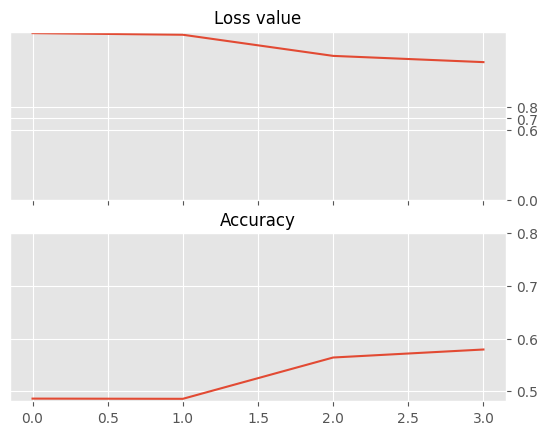

In [11]:
# plot the result
# import pandas as pd
records = pd.read_csv(modelname+'.csv')
plt.figure()
plt.subplot(211)
plt.plot(records['val_loss'])
plt.yticks([0.00,0.60,0.70,0.80])
plt.title('Loss value',fontsize=12)
ax = plt.gca()
ax.set_xticklabels([])
plt.subplot(212)
#plt.plot(records['val_acc'])
plt.plot(records['val_accuracy'])
#plt.plot(records.get('val_accuracy', records.get('val_acc')))
plt.yticks([0.5,0.6,0.7,0.8])
plt.title('Accuracy',fontsize=12)
plt.show()

# CNN

Model: "cifar10CnnCtrl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 668,522 (2.55 MB)

 Trainable params: 667,370 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/60

Epoch 1: val_accuracy improved from None to 0.46000, saving model to cifar10CnnCtrl.keras

Epoch 1: finished saving model to cifar10CnnCtrl.keras
352/352 - 21s - 59ms/step - accuracy: 0.3333 - loss: 2.0222 - val_accuracy: 0.4600 - val_loss: 1.5273 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/60

Epoch 2: val_accuracy improved from 0.46000 to 0.49680, saving model to cifar10CnnCtrl.keras

Epoch 2: finished saving model to cifar10CnnCtrl.keras
352/352 - 10s - 27ms/step - accuracy: 0.4562 - loss: 1.5576 - val_accuracy: 0.4968 - val_loss: 1.4522 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/60

Epoch 3: val_accuracy improved from 0.49680 to 0.55000, saving model to cifar10CnnCtrl.keras

Epoch 3: finished saving model to cifar10CnnCtrl.keras
352/352 - 10s - 28ms/step - accuracy: 0.5159 - loss: 1.4018 - val_accuracy: 

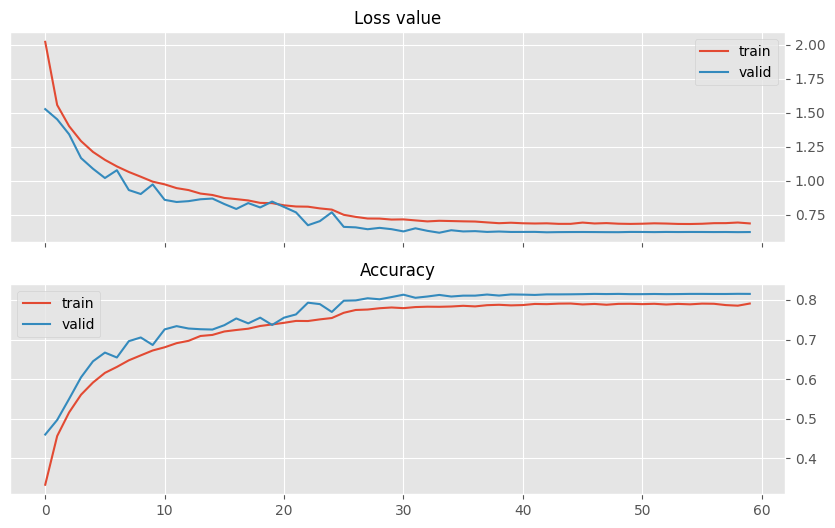

In [12]:
# Shared training recipe for the four models below (CNN / ResNet /
# Transformer / CNN+Transformer), so they are compared on equal terms.
from tensorflow.keras.layers import BatchNormalization, Activation

IMG_SHAPE    = (imgrows, imgclms, channel)   # (32, 32, 3)
BATCH_SIZE   = 128      # slides use 128; their last step was 32
EPOCHS       = 60       # slides use 200
SEED         = 29
WD           = 1e-4     # slides: l2(1e-4)
ROTATION_DEG = 20

keras.utils.set_random_seed(SEED)


# Keras 3 replacement for ImageDataGenerator, which is deprecated.
# Only active inside fit(); evaluate/predict pass straight through.
def augmentation_layers():
    return [
        keras.layers.RandomFlip("horizontal", seed=SEED),
        keras.layers.RandomTranslation(0.10, 0.10,
                                       fill_mode="reflect", seed=SEED),
        # RandomRotation takes a fraction of a turn, not degrees
        keras.layers.RandomRotation(ROTATION_DEG / 360.0,
                                    fill_mode="reflect", seed=SEED),
    ]


def apply_augmentation(x):
    for layer in augmentation_layers():
        x = layer(x)
    return x


# Slides' step ladder (drops at 80/120/140/160 of 200 epochs), rescaled to EPOCHS
def lr_schedule(epoch, lr):
    frac = epoch / float(EPOCHS)
    if   frac > 0.80: return 5e-7
    elif frac > 0.70: return 1e-6
    elif frac > 0.60: return 1e-5
    elif frac > 0.40: return 1e-4
    return 1e-3


# Custom layers to hand to load_model(); the transformer cell fills this in
CUSTOM_OBJECTS = {}


def fit_model(model, modelname):
    model.compile(loss="categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  metrics=["accuracy"])
    checkpoint = ModelCheckpoint(modelname + ".keras", monitor='val_accuracy',
                                 verbose=1, save_best_only=True, mode='max')
    lr_sched   = LearningRateScheduler(lr_schedule, verbose=1)
    csv_logger = CSVLogger(modelname + '.csv')
    # lr_sched must come first: it is what logs learning_rate for the CSV
    return model.fit(X_train, y_train_encoded,
                     epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_valid, y_valid_encoded),
                     callbacks=[checkpoint, lr_sched, csv_logger],
                     verbose=2)


def report_model(modelname):
    model = keras.models.load_model(modelname + ".keras",
                                    custom_objects=CUSTOM_OBJECTS)
    score = model.evaluate(X_test, y_test_encoded, verbose=0)
    print("Best checkpoint [loss, accuracy]:", score)
    y_pred  = model.predict(X_test, verbose=0)
    predout = np.argmax(y_pred, axis=1)
    testout = np.argmax(y_test_encoded, axis=1)
    testScores = metrics.accuracy_score(testout, predout)
    confusion  = metrics.confusion_matrix(testout, predout)
    print("Best accuracy (on testing dataset): %.2f%%" % (testScores * 100))
    print(metrics.classification_report(testout, predout,
                                        target_names=labelname,
                                        digits=4, zero_division=0))
    print(confusion)
    return testScores, confusion


def plot_curves(modelname):
    records = pd.read_csv(modelname + '.csv')
    plt.figure(figsize=(10, 6))
    plt.subplot(211)
    plt.plot(records['loss'],     label='train')
    plt.plot(records['val_loss'], label='valid')
    plt.title('Loss value', fontsize=12)
    plt.legend()
    ax = plt.gca()
    ax.set_xticklabels([])
    plt.subplot(212)
    plt.plot(records['accuracy'],     label='train')
    plt.plot(records['val_accuracy'], label='valid')
    plt.title('Accuracy', fontsize=12)
    plt.legend()
    plt.show()


# CNN control, same recipe as the three models below
modelname = "cifar10CnnCtrl"

model = keras.Sequential([
    keras.layers.Input(shape=IMG_SHAPE),
    *augmentation_layers(),

    Conv2D(32, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    Conv2D(32, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    Conv2D(64, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu',
          kernel_initializer=keras.initializers.HeNormal(seed=SEED)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax'),
], name=modelname)

model.summary()
history = fit_model(model, modelname)
score_test, confusion = report_model(modelname)
plot_curves(modelname)


#ResNet


Model: "ResNetV1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 32, 32, 3) │          0 │ input_layer_2[0]… │
│ (RandomFlip)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 32, 32, 3) │          0 │ random_flip_1[0]… │
│ (RandomTranslation) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 32, 32, 3) │          0 │ random_translati… │
│ (RandomRotation)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Inpt_conv (Conv2D)  │ (None, 32, 32,    │        448 │ random_rotation_… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Inpt_bn             │ (None, 32, 32,    │         64 │ Inpt_conv[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Inpt_relu           │ (None, 32, 32,    │          0 │ Inpt_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk1_Res1_conv │ (None, 32, 32,    │      2,320 │ Inpt_relu[0][0]   │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk1_Res1_bn   │ (None, 32, 32,    │         64 │ Stg1_Blk1_Res1_c… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 32,    │          0 │ Stg1_Blk1_Res1_b… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk1_Res1_relu │ (None, 32, 32,    │          0 │ dropout_4[0][0]   │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk1_Res2_conv │ (None, 32, 32,    │      2,320 │ Stg1_Blk1_Res1_r… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk1_Res2_bn   │ (None, 32, 32,    │         64 │ Stg1_Blk1_Res2_c… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk1_add (Add) │ (None, 32, 32,    │          0 │ Inpt_relu[0][0],  │
│                     │ 16)               │            │ Stg1_Blk1_Res2_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk1_relu      │ (None, 32, 32,    │          0 │ Stg1_Blk1_add[0]… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk2_Res1_conv │ (None, 32, 32,    │      2,320 │ Stg1_Blk1_relu[0… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Stg1_Blk2_Res1_bn   │ (None, 32, 32,    │         64 │ Stg1_Blk2_Res1_c

 Total params: 274,442 (1.05 MB)

 Trainable params: 273,066 (1.04 MB)

 Non-trainable params: 1,376 (5.38 KB)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/60

Epoch 1: val_accuracy improved from None to 0.44960, saving model to cifar10ResV1Full.keras

Epoch 1: finished saving model to cifar10ResV1Full.keras
352/352 - 36s - 104ms/step - accuracy: 0.4027 - loss: 1.8002 - val_accuracy: 0.4496 - val_loss: 1.6731 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/60

Epoch 2: val_accuracy improved from 0.44960 to 0.47580, saving model to cifar10ResV1Full.keras

Epoch 2: finished saving model to cifar10ResV1Full.keras
352/352 - 23s - 65ms/step - accuracy: 0.5176 - loss: 1.4829 - val_accuracy: 0.4758 - val_loss: 1.6499 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/60

Epoch 3: val_accuracy did not improve from 0.47580
352/352 - 22s - 62ms/step - accuracy: 0.5804 - loss: 1.3212 - val_accuracy: 0.4746 - val_loss: 1.8714 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting

Best accuracy (on testing dataset): 85.57%
              precision    recall  f1-score   support

    airplane     0.8390    0.8960    0.8665      1000
  automobile     0.8997    0.9510    0.9246      1000
        bird     0.8268    0.8070    0.8168      1000
         cat     0.7978    0.6630    0.7242      1000
        deer     0.8606    0.8210    0.8403      1000
         dog     0.8496    0.7400    0.7910      1000
        frog     0.7950    0.9460    0.8639      1000
       horse     0.8663    0.9010    0.8833      1000
        ship     0.9400    0.9080    0.9237      1000
       truck     0.8825    0.9240    0.9028      1000

    accuracy                         0.8557     10000
   macro avg     0.8557    0.8557    0.8537     10000
weighted avg     0.8557    0.8557    0.8537     10000

[[896  12  27   4   5   1   5   8  23  19]
 [  7 951   0   1   0   1   0   0   3  37]
 [ 41   5 807  20  27  13  59  19   3   6]
 [ 25  12  40 663  39  87  71  32  12  19]
 [ 12   4  43  22 821  13 

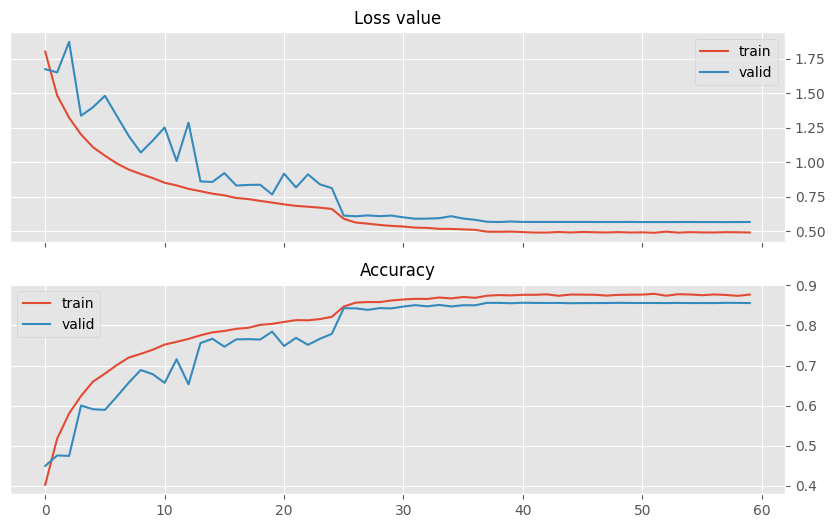

In [13]:
# ResNet v1 from S-PRMLS Day4a.pdf (slides 58-81: resLyr, resBlkV1,
# createResNetV1), built from scratch.
# Keras 3 changes vs the slides:
#   optimizers.Adam(lr=)               -> learning_rate=
#   ImageDataGenerator + fit_generator -> keras.layers.Random* + fit()
#   lrSchedule(epoch)                  -> lr_schedule(epoch, lr)
# dropRate adds the dropout the slides' 78.32% run did not have.
assert 'fit_model' in globals(), "Run the '# CNN' cell first - it defines the shared recipe."


def resLyr(inputs, numFilters=16, kernelSz=3, strides=1,
           activation='relu', batchNorm=True, convFirst=True,
           lyrName=None, dropRate=None):
    convLyr = Conv2D(numFilters,
                     kernel_size=kernelSz,
                     strides=strides, padding='same',
                     kernel_initializer=keras.initializers.HeNormal(seed=SEED),
                     kernel_regularizer=keras.regularizers.l2(WD),
                     name=lyrName + '_conv' if lyrName else None)

    x = inputs

    if convFirst:
        x = convLyr(x)
        if batchNorm:
            x = BatchNormalization(
                name=lyrName + '_bn' if lyrName else None)(x)
        if dropRate:
            x = Dropout(dropRate)(x)
        if activation is not None:
            x = Activation(activation,
                           name=lyrName + '_' + activation if lyrName else None)(x)
    else:
        if batchNorm:
            x = BatchNormalization(
                name=lyrName + '_bn' if lyrName else None)(x)
        if activation is not None:
            x = Activation(activation,
                           name=lyrName + '_' + activation if lyrName else None)(x)
        x = convLyr(x)
    return x


def resBlkV1(inputs, numFilters=16, numBlocks=3,
             downsampleOnFirst=True, names=None, dropRate=None):
    x = inputs

    for run in range(0, numBlocks):
        strides = 1
        blkStr = str(run + 1)
        if downsampleOnFirst and run == 0:
            strides = 2

        y = resLyr(inputs=x,
                   numFilters=numFilters,
                   strides=strides,
                   dropRate=dropRate,
                   lyrName=names + '_Blk' + blkStr + '_Res1' if names else None)
        y = resLyr(inputs=y,
                   numFilters=numFilters,
                   activation=None,
                   lyrName=names + '_Blk' + blkStr + '_Res2' if names else None)

        # shortcut: 1x1 conv when the first block downsamples
        if downsampleOnFirst and run == 0:
            x = resLyr(inputs=x,
                       numFilters=numFilters,
                       kernelSz=1,
                       strides=strides,
                       activation=None,
                       batchNorm=False,
                       lyrName=names + '_Blk' + blkStr + '_lin' if names else None)

        x = keras.layers.Add(
            name=names + '_Blk' + blkStr + '_add' if names else None)([x, y])
        x = Activation('relu',
                       name=names + '_Blk' + blkStr + '_relu' if names else None)(x)

    return x


# 16/32/64 filters, 3 blocks per stage (the slides' createResNetV1)
def createResNetV1(inputShape=(32, 32, 3), numClasses=10, dropRate=0.1):
    inputs = keras.layers.Input(shape=inputShape)

    v = apply_augmentation(inputs)          # replaces ImageDataGenerator
    v = resLyr(inputs=v, lyrName='Inpt')    # stem, stride 1    32x32x16

    v = resBlkV1(inputs=v, numFilters=16, numBlocks=3,
                 downsampleOnFirst=False, names='Stg1', dropRate=dropRate)  # 32x32x16
    v = resBlkV1(inputs=v, numFilters=32, numBlocks=3,
                 downsampleOnFirst=True,  names='Stg2', dropRate=dropRate)  # 16x16x32
    v = resBlkV1(inputs=v, numFilters=64, numBlocks=3,
                 downsampleOnFirst=True,  names='Stg3', dropRate=dropRate)  # 8x8x64

    v = keras.layers.AveragePooling2D(pool_size=8, name='AvgPool')(v)
    v = Flatten()(v)
    outputs = Dense(numClasses, activation='softmax',
                    kernel_initializer=keras.initializers.HeNormal(seed=SEED))(v)

    return keras.Model(inputs=inputs, outputs=outputs, name='ResNetV1')


# Sequential can't express Add(), so this one is functional
modelname = "cifar10ResV1Full"
model = createResNetV1(inputShape=IMG_SHAPE, numClasses=num_classes, dropRate=0.1)
model.summary()
history = fit_model(model, modelname)
score_test, confusion = report_model(modelname)
plot_curves(modelname)


# uncomment for the slides' no-dropout variant (78.32%)
# modelname = "cifar10ResV1NoDrop"
# model = createResNetV1(inputShape=IMG_SHAPE, numClasses=num_classes, dropRate=0.0)
# history = fit_model(model, modelname)
# score_test, confusion = report_model(modelname)
# plot_curves(modelname)


# Transformer (Encoders only)

Model: "cifar10TransEnc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_2            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embed (Conv2D)            │ (None, 8, 8, 128)      │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ to_tokens (Reshape)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pos_embed                       │ (None, 64, 128)        │         8,192 │
│ (ImagePositionalEmbedding)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (TransformerEncoder)  │ (None, 64, 128)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (TransformerEncoder)  │ (None, 64, 128)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_3 (TransformerEncoder)  │ (None, 64, 128)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_4 (TransformerEncoder)  │ (None, 64, 128)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,336,586 (5.10 MB)

 Trainable params: 1,336,586 (5.10 MB)

 Non-trainable params: 0 (0.00 B)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/60

Epoch 1: val_accuracy improved from None to 0.39820, saving model to cifar10TransEnc.keras

Epoch 1: finished saving model to cifar10TransEnc.keras
352/352 - 35s - 99ms/step - accuracy: 0.2945 - loss: 1.9217 - val_accuracy: 0.3982 - val_loss: 1.6742 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/60

Epoch 2: val_accuracy improved from 0.39820 to 0.48840, saving model to cifar10TransEnc.keras

Epoch 2: finished saving model to cifar10TransEnc.keras
352/352 - 24s - 69ms/step - accuracy: 0.4065 - loss: 1.6311 - val_accuracy: 0.4884 - val_loss: 1.4366 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/60

Epoch 3: val_accuracy improved from 0.48840 to 0.53200, saving model to cifar10TransEnc.keras

Epoch 3: finished saving model to cifar10TransEnc.keras
352/352 - 25s - 71ms/step - accuracy: 0.4713 - loss: 1.4776 - val_accu

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'encoder_3', however the layer does not have a

Best checkpoint [loss, accuracy]: [0.755384087562561, 0.7533000111579895]


Best accuracy (on testing dataset): 75.33%
              precision    recall  f1-score   support

    airplane     0.7526    0.8060    0.7784      1000
  automobile     0.7962    0.8830    0.8374      1000
        bird     0.7753    0.6140    0.6853      1000
         cat     0.6789    0.5350    0.5984      1000
        deer     0.7256    0.6690    0.6961      1000
         dog     0.7373    0.6090    0.6670      1000
        frog     0.7018    0.8990    0.7883      1000
       horse     0.7374    0.8340    0.7827      1000
        ship     0.8832    0.8090    0.8445      1000
       truck     0.7517    0.8750    0.8087      1000

    accuracy                         0.7533     10000
   macro avg     0.7540    0.7533    0.7487     10000
weighted avg     0.7540    0.7533    0.7487     10000

[[806  37  30   7   8   2  11  17  39  43]
 [ 15 883   0   1   0   0   4   4   7  86]
 [ 62  18 614  37  65  29  93  53  11  18]
 [ 29  15  43 535  52 122 106  37  15  46]
 [ 21   5  46  23 669  26 

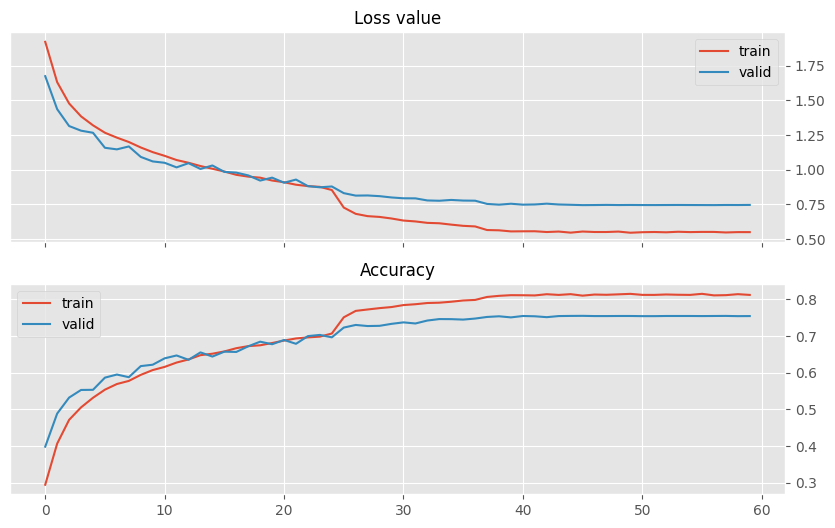

In [15]:
# ViT-style transformer for 32x32: 4x4 patches -> 64 tokens -> encoder stack.
# TransformerEncoder is copied from PRMLS_day4_transformer_encoder.ipynb.
assert 'fit_model' in globals(), "Run the '# CNN' cell first - it defines the shared recipe."


class TransformerEncoder(keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [keras.layers.Dense(dense_dim, activation="relu"),
             keras.layers.Dense(embed_dim)])
        self.layernorm_1 = keras.layers.LayerNormalization()
        self.layernorm_2 = keras.layers.LayerNormalization()

    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        attention_output = self.attention(inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config


# Learned position embedding over the patch grid. Unlike the text version in
# the other notebook this has no compute_mask(); tokens are image features,
# not ids, so masking against 0 is meaningless.
class ImagePositionalEmbedding(keras.layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim = embed_dim
        self.position_embeddings = keras.layers.Embedding(
            input_dim=num_patches, output_dim=embed_dim)

    def build(self, input_shape):
        self.position_embeddings.build((None, self.num_patches))
        super().build(input_shape)

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return inputs + self.position_embeddings(positions)

    def compute_output_shape(self, input_shape):
        return input_shape

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "embed_dim": self.embed_dim,
        })
        return config


# tf.keras here has no .saving, so custom layers are resolved by name instead
CUSTOM_OBJECTS = {"TransformerEncoder": TransformerEncoder,
                  "ImagePositionalEmbedding": ImagePositionalEmbedding}

PATCH_SIZE  = 4
EMBED_DIM   = 128
DENSE_DIM   = 256
NUM_HEADS   = 4
DEPTH       = 4
NUM_PATCHES = (imgrows // PATCH_SIZE) * (imgclms // PATCH_SIZE)   # 8*8 = 64

modelname = "cifar10TransEnc"

model = keras.Sequential([
    keras.layers.Input(shape=IMG_SHAPE),
    *augmentation_layers(),

    # patchify: (32,32,3) -> (8,8,128) -> (64,128)
    Conv2D(EMBED_DIM, kernel_size=PATCH_SIZE, strides=PATCH_SIZE,
           padding='valid', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD), name='patch_embed'),
    keras.layers.Reshape((NUM_PATCHES, EMBED_DIM), name='to_tokens'),

    ImagePositionalEmbedding(NUM_PATCHES, EMBED_DIM, name='pos_embed'),
    Dropout(0.1),

    *[TransformerEncoder(EMBED_DIM, DENSE_DIM, NUM_HEADS,
                         name='encoder_%d' % (i + 1)) for i in range(DEPTH)],

    keras.layers.GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax',
          kernel_initializer=keras.initializers.HeNormal(seed=SEED)),
], name=modelname)

model.summary()
history = fit_model(model, modelname)
score_test, confusion = report_model(modelname)
plot_curves(modelname)


# CNN followed by Transformer Encoders

Model: "cifar10CnnTransEnc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_3            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 810,346 (3.09 MB)

 Trainable params: 809,706 (3.09 MB)

 Non-trainable params: 640 (2.50 KB)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/60

Epoch 1: val_accuracy improved from None to 0.42680, saving model to cifar10CnnTransEnc.keras

Epoch 1: finished saving model to cifar10CnnTransEnc.keras
352/352 - 29s - 83ms/step - accuracy: 0.3962 - loss: 1.7078 - val_accuracy: 0.4268 - val_loss: 1.7780 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/60

Epoch 2: val_accuracy improved from 0.42680 to 0.59240, saving model to cifar10CnnTransEnc.keras

Epoch 2: finished saving model to cifar10CnnTransEnc.keras
352/352 - 21s - 61ms/step - accuracy: 0.5251 - loss: 1.3845 - val_accuracy: 0.5924 - val_loss: 1.2849 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/60

Epoch 3: val_accuracy improved from 0.59240 to 0.61660, saving model to cifar10CnnTransEnc.keras

Epoch 3: finished saving model to cifar10CnnTransEnc.keras
352/352 - 21s - 59ms/step - accuracy: 0.5841 - loss:

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'encoder_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Best checkpoint [loss, accuracy]: [0.5551208257675171, 0.8457000255584717]


Best accuracy (on testing dataset): 84.57%
              precision    recall  f1-score   support

    airplane     0.8665    0.8700    0.8683      1000
  automobile     0.9053    0.9270    0.9160      1000
        bird     0.8390    0.7870    0.8122      1000
         cat     0.7869    0.6390    0.7053      1000
        deer     0.8327    0.8410    0.8368      1000
         dog     0.8231    0.7260    0.7715      1000
        frog     0.7551    0.9560    0.8438      1000
       horse     0.8861    0.8870    0.8866      1000
        ship     0.9120    0.9120    0.9120      1000
       truck     0.8579    0.9120    0.8841      1000

    accuracy                         0.8457     10000
   macro avg     0.8465    0.8457    0.8437     10000
weighted avg     0.8465    0.8457    0.8437     10000

[[870  14  31   4   8   1   8   5  32  27]
 [  4 927   0   2   0   0   3   2  11  51]
 [ 32   4 787  21  30  25  69  20   4   8]
 [ 15  10  42 639  48  98  94  20  14  20]
 [  4   1  31  14 841  15 

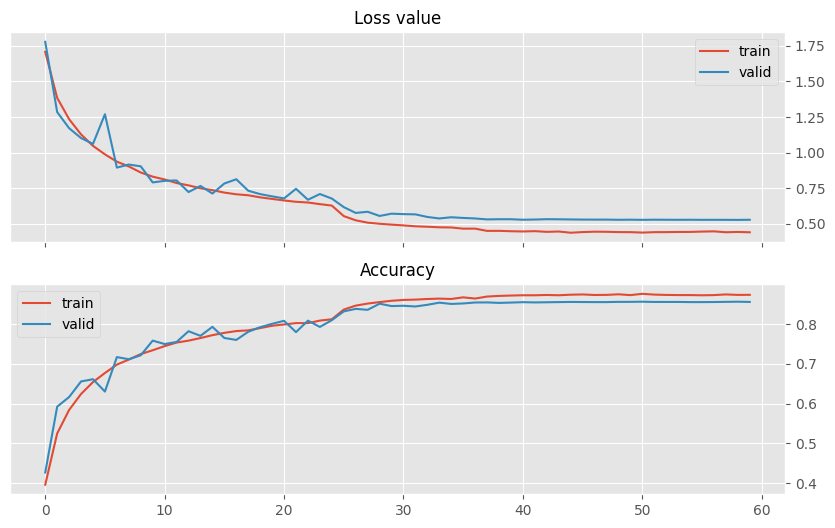

In [16]:
# CNN feature extractor -> 64 tokens -> 2 transformer encoders.
assert 'fit_model' in globals(), "Run the '# CNN' cell first - it defines the shared recipe."
assert 'TransformerEncoder' in globals(), "Run the '# Transformer' cell first - it defines the encoder."

CNN_WIDTH  = 128
EMBED_DIM  = 128
DENSE_DIM  = 256
NUM_HEADS  = 4
DEPTH      = 2
NUM_TOKENS = 64          # 8 x 8 grid

modelname = "cifar10CnnTransEnc"

model = keras.Sequential([
    keras.layers.Input(shape=IMG_SHAPE),
    *augmentation_layers(),

    # CNN: 32 -> 16 -> 8
    Conv2D(32, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    Conv2D(32, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),                 # 16 x 16
    Dropout(0.2),

    Conv2D(64, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    Conv2D(64, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),                 # 8 x 8
    Dropout(0.3),

    Conv2D(CNN_WIDTH, (3, 3), padding='same', use_bias=False,
           kernel_initializer=keras.initializers.HeNormal(seed=SEED),
           kernel_regularizer=keras.regularizers.l2(WD)),
    BatchNormalization(), Activation('relu'),       # 8 x 8 x 128

    # one token per spatial position, then encode
    keras.layers.Reshape((NUM_TOKENS, EMBED_DIM), name='to_tokens'),
    ImagePositionalEmbedding(NUM_TOKENS, EMBED_DIM, name='pos_embed'),

    *[TransformerEncoder(EMBED_DIM, DENSE_DIM, NUM_HEADS,
                         name='encoder_%d' % (i + 1)) for i in range(DEPTH)],

    keras.layers.GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(num_classes, activation='softmax',
          kernel_initializer=keras.initializers.HeNormal(seed=SEED)),
], name=modelname)

model.summary()
history = fit_model(model, modelname)
score_test, confusion = report_model(modelname)
plot_curves(modelname)
